<a href="https://colab.research.google.com/github/Jumi989/Hotel-Booking-System/blob/main/openEnded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/ai_job_replacement_2020_2026_v2.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

Dimension Reduction

In [ ]:
import numpy as np
numeric_cols = [
    'automation_risk_percent',
    'ai_replacement_score',
    'skill_gap_index',
    'salary_before_usd',
    'salary_after_usd',
    'salary_change_percent',
    'skill_demand_growth_percent',
    'remote_feasibility_score',
    'ai_adoption_level',
    'skill_transition_pressure',
    'wage_volatility_index',
    'reskilling_urgency_score',
    'ai_disruption_intensity'
]

X = df[numeric_cols]

#Standardize the data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

#variance explained
explained_variance = pca.explained_variance_ratio_

print(explained_variance)
print("Cumulative:", np.cumsum(explained_variance))

#for better visualization creating 2 components
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

[2.94144195e-01 1.53664879e-01 1.34821866e-01 9.97293136e-02
 7.97271505e-02 7.72317230e-02 7.62665392e-02 7.53829410e-02
 5.77140928e-03 2.90124803e-03 3.58734565e-04 2.36325974e-17
 0.00000000e+00]
Cumulative: [0.2941442  0.44780907 0.58263094 0.68236025 0.7620874  0.83931913
 0.91558567 0.99096861 0.99674002 0.99964127 1.         1.
 1.        ]


Visualizations

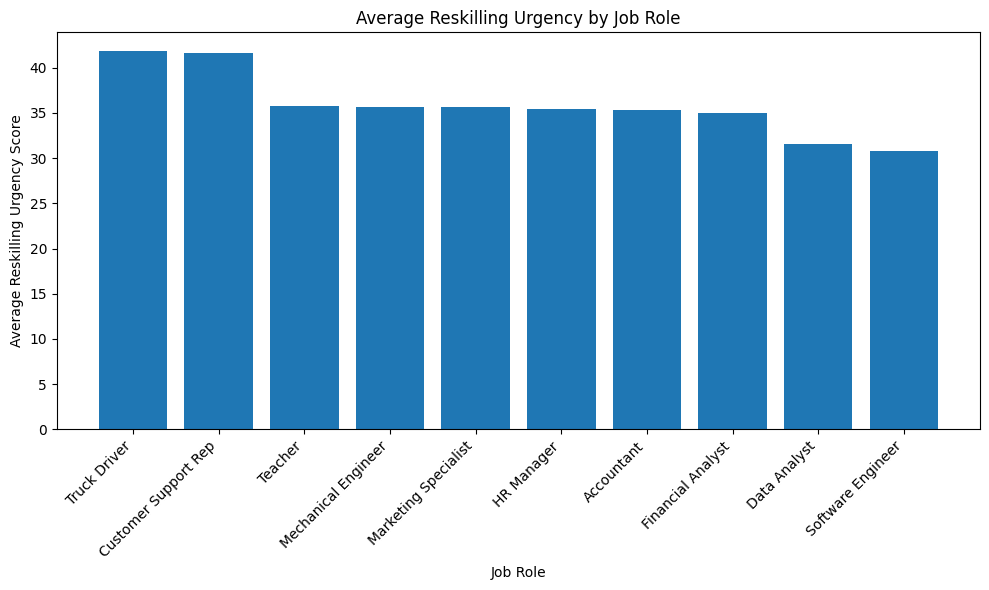

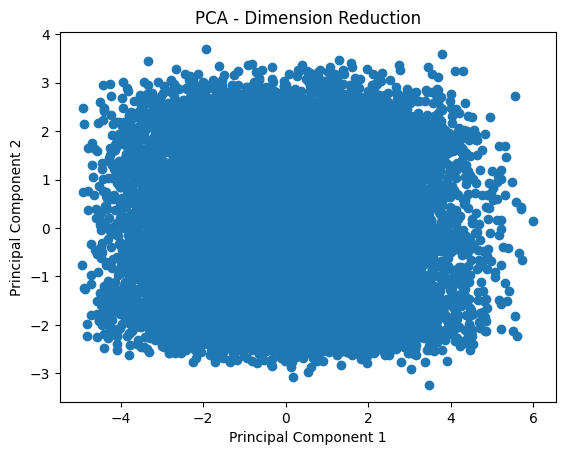

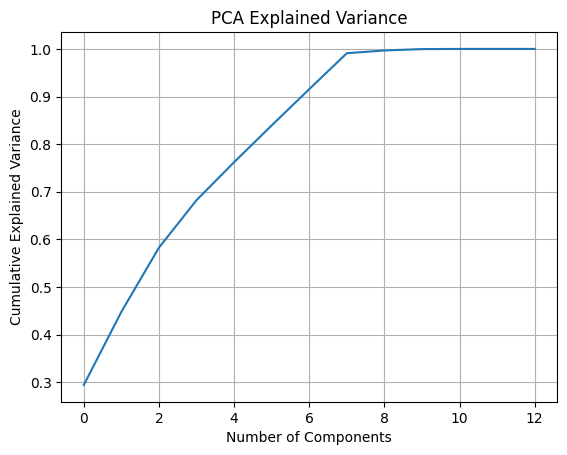

In [ ]:
import matplotlib.pyplot as plt

# Reskilling urgency analysis
df = pd.read_csv("/content/ai_job_replacement_2020_2026_v2.csv")
reskill_df = df.groupby("job_role")["reskilling_urgency_score"].mean().reset_index()
reskill_df = reskill_df.sort_values(by="reskilling_urgency_score", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(reskill_df["job_role"], reskill_df["reskilling_urgency_score"])

plt.xlabel("Job Role")
plt.ylabel("Average Reskilling Urgency Score")
plt.title("Average Reskilling Urgency by Job Role")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Dimension Reduction")
plt.show()

plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

ML Training

In [ ]:
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AI Job Replacement ML") \
    .getOrCreate()
spark_df = spark.read.csv(
    "/content/ai_job_replacement_2020_2026_v2.csv",
    header=True,
    inferSchema=True
     )

spark_df.show(5)
spark_df.printSchema()

+------+--------------------+-------------+-------+----+-----------------------+--------------------+---------------+-----------------+----------------+---------------------+---------------------------+------------------------+-----------------+---------------------------+------------------------+-------------------------+---------------------+------------------------+-----------------------+
|job_id|            job_role|     industry|country|year|automation_risk_percent|ai_replacement_score|skill_gap_index|salary_before_usd|salary_after_usd|salary_change_percent|skill_demand_growth_percent|remote_feasibility_score|ai_adoption_level|education_requirement_level|automation_risk_category|skill_transition_pressure|wage_volatility_index|reskilling_urgency_score|ai_disruption_intensity|
+------+--------------------+-------------+-------+----+-----------------------+--------------------+---------------+-----------------+----------------+---------------------+---------------------------+------

In [ ]:
categorical_cols = ["job_role", "industry", "country"]

numeric_cols = [
    "year",
    "ai_replacement_score",
    "skill_gap_index",
    "salary_before_usd",
    "salary_after_usd",
    "salary_change_percent",
    "skill_demand_growth_percent",
    "remote_feasibility_score",
    "ai_adoption_level",
    "education_requirement_level",
    "skill_transition_pressure",
    "wage_volatility_index",
    "reskilling_urgency_score",
    "ai_disruption_intensity"
]

# encoding categorical columns
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=col + "_index",
        outputCol=col + "_vec"
    )
    for col in categorical_cols
]

label_indexer = StringIndexer(
    inputCol="automation_risk_category",
    outputCol="label",
    handleInvalid="keep"
)

In [ ]:
#Assembling
feature_cols = numeric_cols + [col + "_vec" for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_data, test_data = spark_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_data.count())
print("Testing rows:", test_data.count())

#Model training
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=8,
    seed=42
)

pipeline = Pipeline(
    stages=indexers + encoders + [label_indexer, assembler, rf]
)

model = pipeline.fit(train_data)

Training rows: 12058
Testing rows: 2942


In [ ]:
predictions = model.transform(test_data)

predictions.select(
    "job_role",
    "industry",
    "country",
    "automation_risk_category",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+--------------------+--------------+---------+------------------------+-----+----------+------------------------------------------------------------------+
|job_role            |industry      |country  |automation_risk_category|label|prediction|probability                                                       |
+--------------------+--------------+---------+------------------------+-----+----------+------------------------------------------------------------------+
|Teacher             |Technology    |USA      |Medium                  |0.0  |0.0       |[0.7364236094604278,0.10415174124016459,0.15942464929940747,0.0]  |
|Accountant          |Manufacturing |Australia|Medium                  |0.0  |0.0       |[0.794941200202981,0.15534544257888358,0.04971335721813544,0.0]   |
|Marketing Specialist|Retail        |USA      |Low                     |2.0  |2.0       |[0.04624391168130682,0.002961682425494132,0.950794405893199,0.0]  |
|Accountant          |Education     |Australia|Medium     

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

accuracy = accuracy_evaluator.evaluate(predictions)
f1 = f1_evaluator.evaluate(predictions)
precision = precision_evaluator.evaluate(predictions)
recall = recall_evaluator.evaluate(predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

predictions.groupBy("label", "prediction").count().show()

Accuracy: 0.8942895989123045
F1 Score: 0.8943507767488685
Precision: 0.8947351922040523
Recall: 0.8942895989123045
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  2.0|       0.0|   53|
|  1.0|       1.0|  780|
|  0.0|       1.0|  124|
|  2.0|       2.0|  716|
|  1.0|       0.0|   88|
|  0.0|       0.0| 1135|
|  0.0|       2.0|   46|
+-----+----------+-----+



Normal ML using scikit-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
df = pd.read_csv("/content/ai_job_replacement_2020_2026_v2.csv")

df.head()
big_df = pd.concat([df]*50, ignore_index=True)
print(big_df.shape)
target = "automation_risk_category"

categorical_cols = ["job_role", "industry", "country"]

numeric_cols = [
    "year",
    "ai_replacement_score",
    "skill_gap_index",
    "salary_before_usd",
    "salary_after_usd",
    "salary_change_percent",
    "skill_demand_growth_percent",
    "remote_feasibility_score",
    "ai_adoption_level",
    "education_requirement_level",
    "skill_transition_pressure",
    "wage_volatility_index",
    "reskilling_urgency_score",
    "ai_disruption_intensity"
]

X = big_df[numeric_cols + categorical_cols]
y = big_df[target]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

(750000, 20)


RandomForestClassifier(max_depth=8, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9200933333333333
Precision: 0.9209260209301922
Recall: 0.9200933333333333
F1 Score: 0.9202834005735477

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.92      0.92     44960
         Low       0.96      0.92      0.94     40400
      Medium       0.90      0.92      0.91     64640

    accuracy                           0.92    150000
   macro avg       0.93      0.92      0.92    150000
weighted avg       0.92      0.92      0.92    150000


Confusion Matrix:
[[41468     0  3492]
 [    0 37019  3381]
 [ 3680  1433 59527]]
